## Case Study 05: Firewall Traffic
- Build a program about whether or not to accept or deny access to requests coming in.
- Model should filter incoming requests, classify them, auto accept or deny.
- Best, most advanced model---accuracy, and function at speed
- 60,000 rows
- report on level of accuracy and level of performance
- target: action
- port - an address (web traffic, port 80; secure channel 22)
- Use SVM and SGD to attempt to model and predict the class of an internet connection request.
- ALL FOUR CLASSES MUST BE INCLUDED!

### Case Study Overview from Live Session Transcript

* The dataset is related to **internet connections**, and the goal is to **predict the action** taken (e.g., allow, deny, drop, reset-both).
* It's a **4-class classification problem**, but one class is *severely underrepresented* (e.g., "maybe 50 examples out of 100,000").
* You **shouldn’t worry** if you get 0% accuracy on that rare class — it’s expected and will show up clearly in your confusion matrix.
* Most observations are labeled `'allow'`, followed by `'deny'` and `'drop'`, with `'reset-both'` being very rare.

### EDA Guidance

* The dataset contains a **lot of unique port values** (e.g., `Destination Port`, `NAT Destination Port`), but these should be treated as **categorical variables**, not numeric ones.
* Ports should be **grouped** using frequency-based rules — i.e., treat rare ports as an "infrequent port" category.
* He specifically says:

  > "Do a good EDA… make some reasonable guesses about how to group these ports together."
  > And:
  > "If a port appears in fewer than 5–10 examples, just lump it into an infrequent category".
* This helps avoid exploding the feature space when one-hot encoding.

### One-Hot Encoding

* Ports and some of the first few columns (like `Source Port`, `Destination Port`, etc.) are categorical and **must be one-hot encoded**.
* But instead of blindly one-hot encoding thousands of unique port values, group them first:

  > “Try and handle this data in an appropriate manner… see if you can group them together, like put the infrequent ports together and make one giant category”.
* He mentions the dataset will be “**fat**” (many features) due to one-hot encoding, so pruning categories through EDA is key.


- For modeling: LinearSVC, SVC(kernel='rbf'), can double cache size (to 400)
- Stick with tuning C for SVC
- squared hinge loss with penalize outliers more

In [2]:
# Import standard libraries
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# import modeling libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, log_loss
from sklearn.base import clone

# Set global seed
SEED = 13

### Import, view and describe the data

In [3]:
raw_data = pd.read_csv('data/log2.csv')
raw_data

,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Action,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
0,57222,53,54587,53,allow,177,94,83,2,30,1,1
1,56258,3389,56258,3389,allow,4768,1600,3168,19,17,10,9
2,6881,50321,43265,50321,allow,238,118,120,2,1199,1,1
3,50553,3389,50553,3389,allow,3327,1438,1889,15,17,8,7
4,50002,443,45848,443,allow,25358,6778,18580,31,16,13,18
...,...,...,...,...,...,...,...,...,...,...,...,...
65527,63691,80,13237,80,allow,314,192,122,6,15,4,2
65528,50964,80,13485,80,allow,4680740,67312,4613428,4675,77,985,3690
65529,54871,445,0,0,drop,70,70,0,1,0,1,0
65530,54870,445,0,0,drop,70,70,0,1,0,1,0


In [4]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65532 entries, 0 to 65531
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Source Port           65532 non-null  int64 
 1   Destination Port      65532 non-null  int64 
 2   NAT Source Port       65532 non-null  int64 
 3   NAT Destination Port  65532 non-null  int64 
 4   Action                65532 non-null  object
 5   Bytes                 65532 non-null  int64 
 6   Bytes Sent            65532 non-null  int64 
 7   Bytes Received        65532 non-null  int64 
 8   Packets               65532 non-null  int64 
 9   Elapsed Time (sec)    65532 non-null  int64 
 10  pkts_sent             65532 non-null  int64 
 11  pkts_received         65532 non-null  int64 
dtypes: int64(11), object(1)
memory usage: 6.0+ MB


In [5]:
raw_data.describe()

,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
count,65532.000000,65532.000000,65532.000000,65532.000000,6.553200e+04,6.553200e+04,6.553200e+04,6.553200e+04,65532.000000,65532.000000,65532.000000
mean,49391.969343,10577.385812,19282.972761,2671.049930,9.712395e+04,2.238580e+04,7.473815e+04,1.028660e+02,65.833577,41.399530,61.466505
std,15255.712537,18466.027039,21970.689669,9739.162278,5.618439e+06,3.828139e+06,2.463208e+06,5.133002e+03,302.461762,3218.871288,2223.332271
min,0.000000,0.000000,0.000000,0.000000,6.000000e+01,6.000000e+01,0.000000e+00,1.000000e+00,0.000000,1.000000,0.000000
25%,49183.000000,80.000000,0.000000,0.000000,6.600000e+01,6.600000e+01,0.000000e+00,1.000000e+00,0.000000,1.000000,0.000000
50%,53776.500000,445.000000,8820.500000,53.000000,1.680000e+02,9.000000e+01,7.900000e+01,2.000000e+00,15.000000,1.000000,1.000000
75%,58638.000000,15000.000000,38366.250000,443.000000,7.522500e+02,2.100000e+02,4.490000e+02,6.000000e+00,30.000000,3.000000,2.000000
max,65534.000000,65535.000000,65535.000000,65535.000000,1.269359e+09,9.484772e+08,3.208818e+08,1.036116e+06,10824.000000,747520.000000,327208.000000


There are no missing values!

### What is the distribution of the response classes?

In [6]:
# Find the proportion of each response class
print(raw_data['Action'].value_counts()/raw_data['Action'].count())

Action
allow         0.574376
deny          0.228697
drop          0.196103
reset-both    0.000824
Name: count, dtype: float64


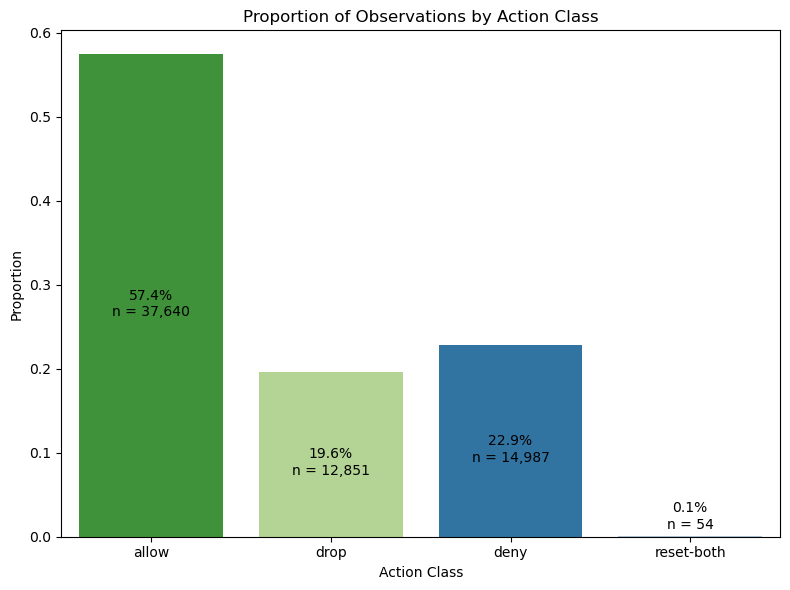

In [7]:
# Set the color palette
palette = sns.color_palette("Paired", n_colors=len(raw_data['Action'].unique()))[::-1]

# Calculate counts and proportions of each category
class_counts = raw_data['Action'].value_counts(sort=False)  # Counts
class_proportions = class_counts / class_counts.sum()  # Proportions

# Create a DataFrame for plotting with proper labels
plot_df = pd.DataFrame({
    # 'class_label': [labels[i] for i in class_counts.index],
    'class_label': raw_data['Action'].unique(),
    'proportion': class_proportions.values,
    'count': class_counts.values
})

# Plot the distribution
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(
    x='class_label',
    y='proportion', 
    data=plot_df,
    palette=palette, 
    hue='class_label',
    ax=ax
)

# Remove the legend (redundant with x-axis labels)
ax.get_legend().remove() if ax.get_legend() else None

# Add titles and labels
ax.set_title('Proportion of Observations by Action Class')
ax.set_xlabel('Action Class')
ax.set_ylabel('Proportion')

# Threshold below which the label will be placed *above* the bar
threshold = 0.05  # Adjust as needed based on your data

for i, (bar, count) in enumerate(zip(ax.patches, plot_df['count'])):
    height = bar.get_height()
    percentage = plot_df['proportion'].iloc[i] * 100

    # Percentage label: inside if tall enough, else above
    if height > threshold:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{percentage:.1f}%',
            ha='center', va='center',
            fontsize=10,
            color='black'
        )
            # Count label on top
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height / 2 - 0.02,
            f'n = {count:,}',
            ha='center', va='center',
            fontsize=10
        )
    else:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.025,
            f'{percentage:.1f}%',
            ha='center', va='bottom',
            fontsize=10,
            color='black'
        )
            # Count label on top
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.005,
            f'n = {count:,}',
            ha='center', va='bottom',
            fontsize=10
        )

plt.tight_layout()
plt.show()

### Investigate the Ports

In [8]:
# I'm curious about Destination Port and NAT Destination Port.

print('allow class counts with non-matching Destination and NAT Destination Port values:') 
# Are they the same for the allow class?
subset = raw_data[raw_data['Action'] == 'allow']
mismatch_count = sum(subset['Destination Port'] != subset['NAT Destination Port'])
print(mismatch_count)
# What is the NAT Destination Port for the ones that don't match?
mismatches = subset[subset['Destination Port'] != subset['NAT Destination Port']]
print(mismatches['NAT Destination Port'].value_counts())

# Is NAT DP 0 for all the drop, deny, reset-both?
print('drop class counts with non-zero NAT Destination Port values:')
subset = raw_data[raw_data['Action'] == 'drop']
nonzero_count = sum(subset['NAT Destination Port'] != 0)
print(nonzero_count)

# Is NAT DP 0 for all the drop, deny, reset-both?
print('deny class counts with non-zero NAT Destination Port values:')
subset = raw_data[raw_data['Action'] == 'deny']
nonzero_count = sum(subset['NAT Destination Port'] != 0)
print(nonzero_count)
# What is the NAT Destination Port for the ones that aren't zero?
nonzeros = subset[subset['NAT Destination Port'] != 0]
print(nonzeros['NAT Destination Port'].value_counts())

# Is NAT DP 0 for all the drop, deny, reset-both?
print('reset-both class counts with non-zero NAT Destination Port values:')
subset = raw_data[raw_data['Action'] == 'reset-both']
nonzero_count = sum(subset['NAT Destination Port'] != 0)
print(nonzero_count)
# What is the NAT Destination Port for the ones that aren't zero?
nonzeros = subset[subset['NAT Destination Port'] != 0]
print(nonzeros['NAT Destination Port'].value_counts())

allow class counts with non-matching Destination and NAT Destination Port values:
480
NAT Destination Port
0        479
50706      1
Name: count, dtype: int64
drop class counts with non-zero NAT Destination Port values:
0
deny class counts with non-zero NAT Destination Port values:
12
NAT Destination Port
22      6
8889    2
5169    1
25      1
443     1
8887    1
Name: count, dtype: int64
reset-both class counts with non-zero NAT Destination Port values:
12
NAT Destination Port
3389    12
Name: count, dtype: int64


Often if the Action class is allow, the Destination Port and the NAT Destination Port values match. However, this is not the case for 480 rows. In 479 of those the NAT Destination Port is 0, and the last 1 has a NAT Destination Port of 50706. 

All of the Action class drop have NAT Destination Port 0. And all but 12 of each of the the deny and reset-both classes have NAT Destination Port equal to zero. 

In [9]:
# Let's look at the frequency of the Source Port values (maybe per class)
print(len(raw_data['Source Port'].unique()))
port_counts = raw_data['Source Port'].value_counts()
print(port_counts[port_counts > 9])
print(len(port_counts[port_counts > 9]))

22724
Source Port
58638    840
27005    513
443      273
57470    222
49418    210
        ... 
56937     10
54977     10
49628     10
49183     10
49348     10
Name: count, Length: 403, dtype: int64
403


In [10]:
# Let's look at the frequency of the NAT Source Port values (maybe per class)
print(len(raw_data['NAT Source Port'].unique()))
port_counts = raw_data['NAT Source Port'].value_counts()
print(port_counts[port_counts > 4])
print(len(port_counts[port_counts > 4]))

29152
NAT Source Port
0        28432
48817       83
58638       51
50116       15
7986         5
30399        5
43757        5
57880        5
57596        5
60868        5
14591        5
Name: count, dtype: int64
11


In [11]:
# Let's look at the frequency of the Destination Port values (maybe per class)
print(len(raw_data['Destination Port'].unique()))
port_counts = raw_data['Destination Port'].value_counts()
print(port_counts[port_counts > 4])
print(len(port_counts[port_counts > 4]))

3273
Destination Port
53       15414
445      12891
443      11684
80        4035
25174     1087
         ...  
46478        5
45129        5
40740        5
7205         5
49344        5
Name: count, Length: 373, dtype: int64
373


In [12]:
# Let's look at the frequency of the Destination Port values (maybe per class)
print(len(raw_data['NAT Destination Port'].unique()))
port_counts = raw_data['NAT Destination Port'].value_counts()
print(port_counts)
print(port_counts[port_counts > 4])
print(len(port_counts[port_counts > 4]))

2533
NAT Destination Port
0        28432
53       15094
443      11678
80        4028
27015      234
         ...  
45561        1
45738        1
41872        1
25760        1
32277        1
Name: count, Length: 2533, dtype: int64
NAT Destination Port
0        28432
53       15094
443      11678
80        4028
27015      234
         ...  
27111        5
59208        5
30008        5
64509        5
30006        5
Name: count, Length: 109, dtype: int64
109


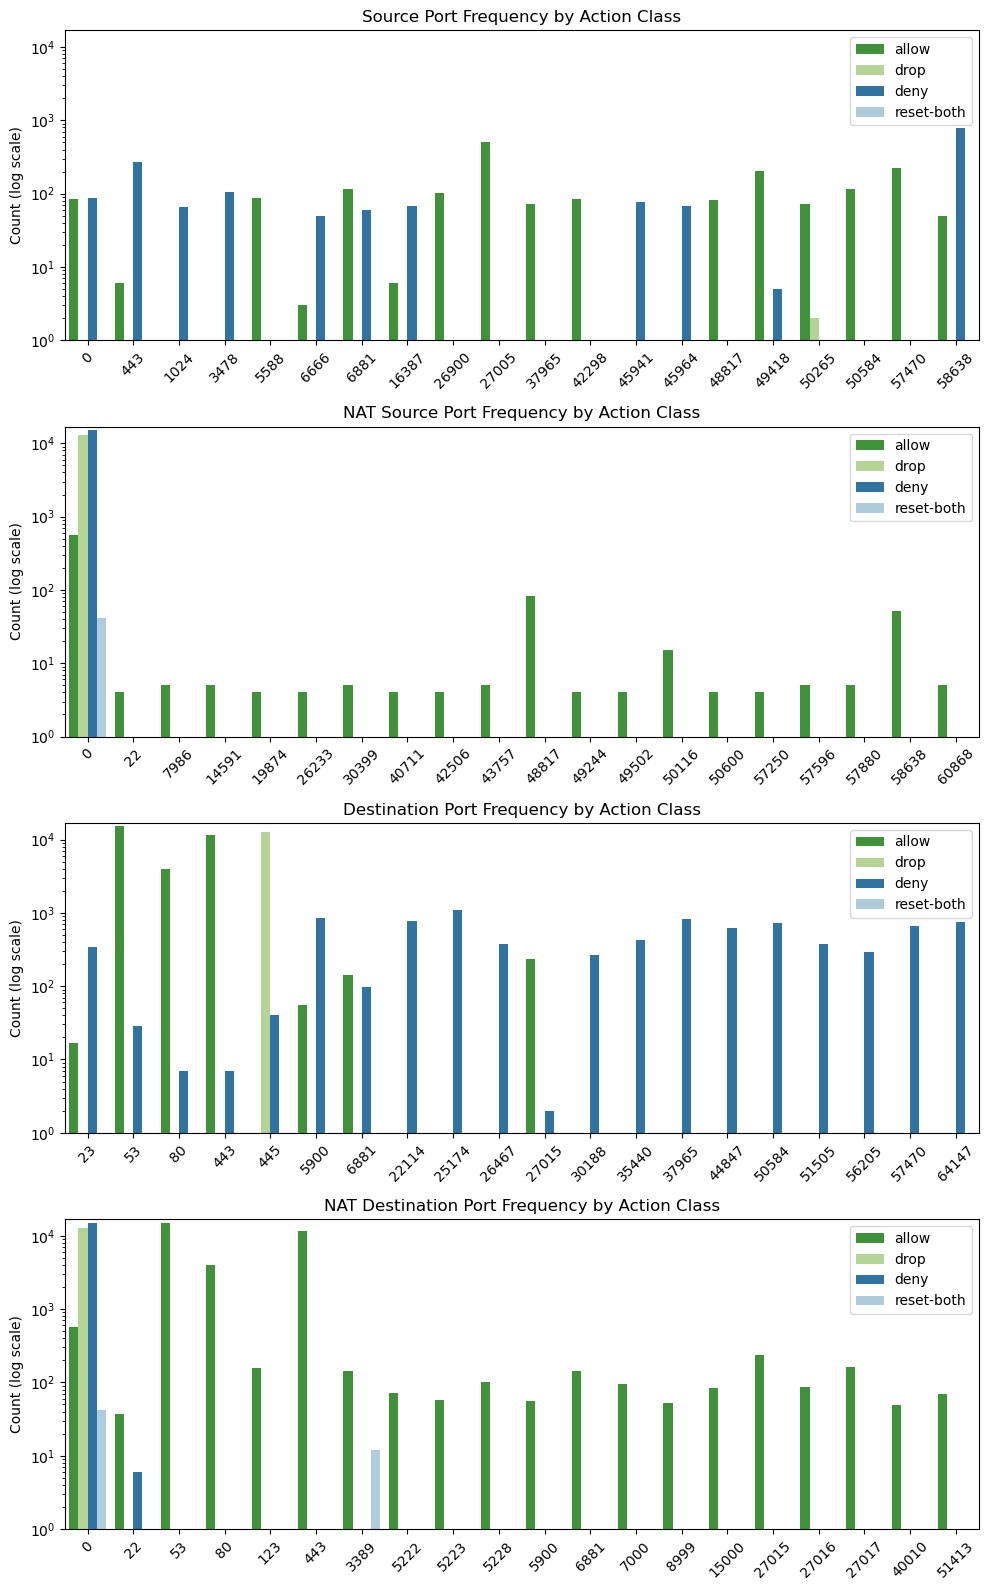

In [13]:
port_cols = ['Source Port', 'NAT Source Port', 'Destination Port', 'NAT Destination Port']
palette = sns.color_palette("Paired", n_colors=len(raw_data['Action'].unique()))[::-1]
action_order = ['allow', 'drop', 'deny', 'reset-both']

fig, axes = plt.subplots(4, 1, figsize=(10, 16), sharex=False)

max_count = 0  # for setting y-axis limits consistently

# First pass: find max count for y-limit
for col in port_cols:
    top_ports = raw_data[col].value_counts().nlargest(20).index
    filtered_df = raw_data[raw_data[col].isin(top_ports)]
    counts = (
        filtered_df.groupby(['Action', col])
        .size()
        .reset_index(name='count')
    )
    max_count = max(max_count, counts['count'].max())

# Second pass: plot with matched y-limits and log scale
for i, col in enumerate(port_cols):
    ax = axes[i]
    top_ports = raw_data[col].value_counts().nlargest(20).index
    filtered_df = raw_data[raw_data[col].isin(top_ports)]
    port_action_counts = (
        filtered_df.groupby(['Action', col])
        .size()
        .reset_index(name='count')
        .sort_values(by='count', ascending=False)
    )

    sns.barplot(
        data=port_action_counts,
        x=col,
        y='count',
        hue='Action',
        hue_order=action_order,         # <---- force palette mapping to match
        palette=palette,
        ax=ax
    )

    ax.set_title(f'{col} Frequency by Action Class')
    ax.set_ylabel('Count (log scale)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.set_yscale('log')
    ax.set_ylim(1, max_count * 1.1)  # add headroom
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

Top 20 most frequent ports overall for each port type (Source Port, NAT Source Port, Destination Port, NAT Destination Port), grouped by Action class. The y-axis is log-scaled to reveal rare port usage. allow actions dominate well-known service ports like 80 (HTTP), 443 (HTTPS), and 53 (DNS) in the Destination and NAT Destination fields. deny and drop actions are more prevalent on ports associated with remote access or blocked services, including 22 (SSH), 23 (Telnet), 445 (SMB), and 5900 (VNC). Interestingly, 443 appears in Source Port with more deny than allow actions, suggesting misclassified or suspicious outbound traffic. Port 3389 (RDP) is mostly allowed, with occasional resets indicating session terminations. Source ports are primarily high-numbered ephemeral values, especially in allow traffic, while NAT Source Port shows a concentration at port 0, likely reflecting missing or anonymized NAT data. The side-by-side bar format highlights class-specific usage patterns and confirms that port characteristics are strongly associated with observed actions.

Common Ports and their use cases:

| **Port** | **Service**       | **Typical Use Case**                                         |
|----------|-------------------|--------------------------------------------------------------|
| 0        | —                 | Placeholder or missing NAT info                              |
| 22       | SSH               | Secure remote access (often blocked or logged)               |
| 23       | Telnet            | Insecure remote terminal access (commonly denied or blocked) |
| 53       | DNS               | Domain name resolution                                       |
| 80       | HTTP              | Standard web traffic                                         |
| 110      | POP3              | Incoming email                                               |
| 135      | MS RPC            | Microsoft RPC (internal Windows use)                         |
| 139      | NetBIOS           | Windows network file sharing                                 |
| 143      | IMAP              | Incoming email                                               |
| 443      | HTTPS             | Secure web traffic; may appear in source ports (ephemeral)   |
| 445      | SMB               | Windows file sharing; often blocked due to vulnerabilities   |
| 3389     | RDP               | Remote Desktop Protocol; sometimes allowed, sometimes reset  |
| 5900     | VNC               | Remote desktop/control (often blocked)                       |
| 8080     | HTTP-alt          | Web proxy / alternative web port                             |

High-numbered ports (≥1024), often observed in the Source Port field, represent ephemeral client-side connections and are typical of outbound traffic in allow actions. Their presence in Destination Port or NAT-related fields may indicate non-standard routing or potential anomalies.

### Group Infrequently Used Ports into and Infrequent Category

In [14]:
# Copy the raw dataset
data_grouped = raw_data.copy()

# Define a grouping function for grouping categories below a count threshold
def group_infrequent(series, threshold):
    """
    Replace values with 'infrequent' if their count is below the threshold.
    """
    value_counts = series.value_counts()
    frequent_values = value_counts[value_counts >= threshold].index
    return series.apply(lambda x: x if x in frequent_values else 'infrequent')

# Replace port columns with grouped versions (to keep one-hot-encoded and numeric features to < 1000)
data_grouped['Source Port'] = group_infrequent(data_grouped['Source Port'], threshold=10) # 10 leaves 404 categories, but 87% grouped
data_grouped['NAT Source Port'] = group_infrequent(data_grouped['NAT Source Port'], threshold=5) # leaves 12 categories
data_grouped['Destination Port'] = group_infrequent(data_grouped['Destination Port'], threshold=5) # leaves 373 categories
data_grouped['NAT Destination Port'] = group_infrequent(data_grouped['NAT Destination Port'], threshold=5) # leaves 110 categories

for col in ['Source Port', 'NAT Source Port', 'Destination Port', 'NAT Destination Port']:
    print(f"\n{col} value counts after grouping:")
    print(data_grouped[col].value_counts().head(10))
    print(f"Total unique values: {data_grouped[col].nunique()}")

for col in ['Source Port', 'NAT Source Port', 'Destination Port', 'NAT Destination Port']:
    original_unique = raw_data[col].nunique()
    grouped_unique = data_grouped[col].nunique()
    print(f"{col}: {original_unique} → {grouped_unique} categories after grouping")

for col in ['Source Port', 'NAT Source Port', 'Destination Port', 'NAT Destination Port']:
    infrequent_count = (data_grouped[col] == 'infrequent').sum()
    total = len(data_grouped)
    print(f"{col}: {infrequent_count} rows labeled 'infrequent' ({infrequent_count / total:.2%})")



Source Port value counts after grouping:
Source Port
infrequent    56960
58638           840
27005           513
443             273
57470           222
49418           210
6881            177
0               173
50584           116
3478            105
Name: count, dtype: int64
Total unique values: 404

NAT Source Port value counts after grouping:
NAT Source Port
infrequent    36916
0             28432
48817            83
58638            51
50116            15
7986              5
57880             5
43757             5
57596             5
60868             5
Name: count, dtype: int64
Total unique values: 12

Destination Port value counts after grouping:
Destination Port
53            15414
445           12891
443           11684
infrequent     4610
80             4035
25174          1087
5900            909
37965           826
22114           767
64147           756
Name: count, dtype: int64
Total unique values: 374

NAT Destination Port value counts after grouping:
NAT Destination P

In [15]:
data_grouped.columns

Index(['Source Port', 'Destination Port', 'NAT Source Port',
       'NAT Destination Port', 'Action', 'Bytes', 'Bytes Sent',
       'Bytes Received', 'Packets', 'Elapsed Time (sec)', 'pkts_sent',
       'pkts_received'],
      dtype='object')

In [16]:
data_grouped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65532 entries, 0 to 65531
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Source Port           65532 non-null  object
 1   Destination Port      65532 non-null  object
 2   NAT Source Port       65532 non-null  object
 3   NAT Destination Port  65532 non-null  object
 4   Action                65532 non-null  object
 5   Bytes                 65532 non-null  int64 
 6   Bytes Sent            65532 non-null  int64 
 7   Bytes Received        65532 non-null  int64 
 8   Packets               65532 non-null  int64 
 9   Elapsed Time (sec)    65532 non-null  int64 
 10  pkts_sent             65532 non-null  int64 
 11  pkts_received         65532 non-null  int64 
dtypes: int64(7), object(5)
memory usage: 6.0+ MB


### Examine the Distributions of the Numeric Variables

In [17]:
with pd.option_context('display.float_format', '{:.2f}'.format):
    for action in data_grouped['Action'].unique():
        print(f"\n==== Descriptive Stats for Action: {action} ====")
        display(data_grouped[data_grouped['Action'] == action].describe())


==== Descriptive Stats for Action: allow ====


,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
count,37640.00,37640.00,37640.00,37640.00,37640.00,37640.00,37640.00
mean,169037.95,38917.41,130120.54,178.35,114.62,71.33,107.01
std,7412624.62,5051106.82,3249056.06,6771.93,392.03,4247.00,2932.82
min,60.00,60.00,0.00,1.00,0.00,1.00,0.00
25%,194.00,94.00,91.00,2.00,27.00,1.00,1.00
50%,422.00,126.00,220.00,3.00,30.00,2.00,1.00
75%,5166.00,1586.00,3063.25,19.00,49.00,10.00,9.00
max,1269359015.00,948477220.00,320881795.00,1036116.00,10824.00,747520.00,327208.00



==== Descriptive Stats for Action: drop ====


,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
count,12851.00,12851.00,12851.00,12851.00,12851.00,12851.00,12851.00
mean,68.68,68.68,0.00,1.00,0.00,1.00,0.00
std,1.88,1.88,0.00,0.00,0.00,0.00,0.00
min,66.00,66.00,0.00,1.00,0.00,1.00,0.00
25%,66.00,66.00,0.00,1.00,0.00,1.00,0.00
50%,70.00,70.00,0.00,1.00,0.00,1.00,0.00
75%,70.00,70.00,0.00,1.00,0.00,1.00,0.00
max,70.00,70.00,0.00,1.00,0.00,1.00,0.00



==== Descriptive Stats for Action: deny ====


,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
count,14987.00,14987.00,14987.00,14987.00,14987.00,14987.00,14987.00
mean,83.21,83.04,0.18,1.00,0.00,1.00,0.00
std,88.58,87.31,12.18,0.08,0.01,0.05,0.05
min,60.00,60.00,0.00,1.00,0.00,1.00,0.00
25%,62.00,62.00,0.00,1.00,0.00,1.00,0.00
50%,66.00,66.00,0.00,1.00,0.00,1.00,0.00
75%,66.00,66.00,0.00,1.00,0.00,1.00,0.00
max,1850.00,1514.00,1419.00,5.00,1.00,3.00,2.00



==== Descriptive Stats for Action: reset-both ====


,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
count,54.00,54.00,54.00,54.00,54.00,54.00,54.00
mean,157.35,141.80,15.56,1.67,0.13,1.44,0.22
std,81.32,56.36,29.38,1.26,0.34,0.84,0.42
min,62.00,62.00,0.00,1.00,0.00,1.00,0.00
25%,88.75,88.75,0.00,1.00,0.00,1.00,0.00
50%,145.00,145.00,0.00,1.00,0.00,1.00,0.00
75%,158.50,158.50,0.00,1.00,0.00,1.00,0.00
max,293.00,223.00,70.00,4.00,1.00,3.00,1.00


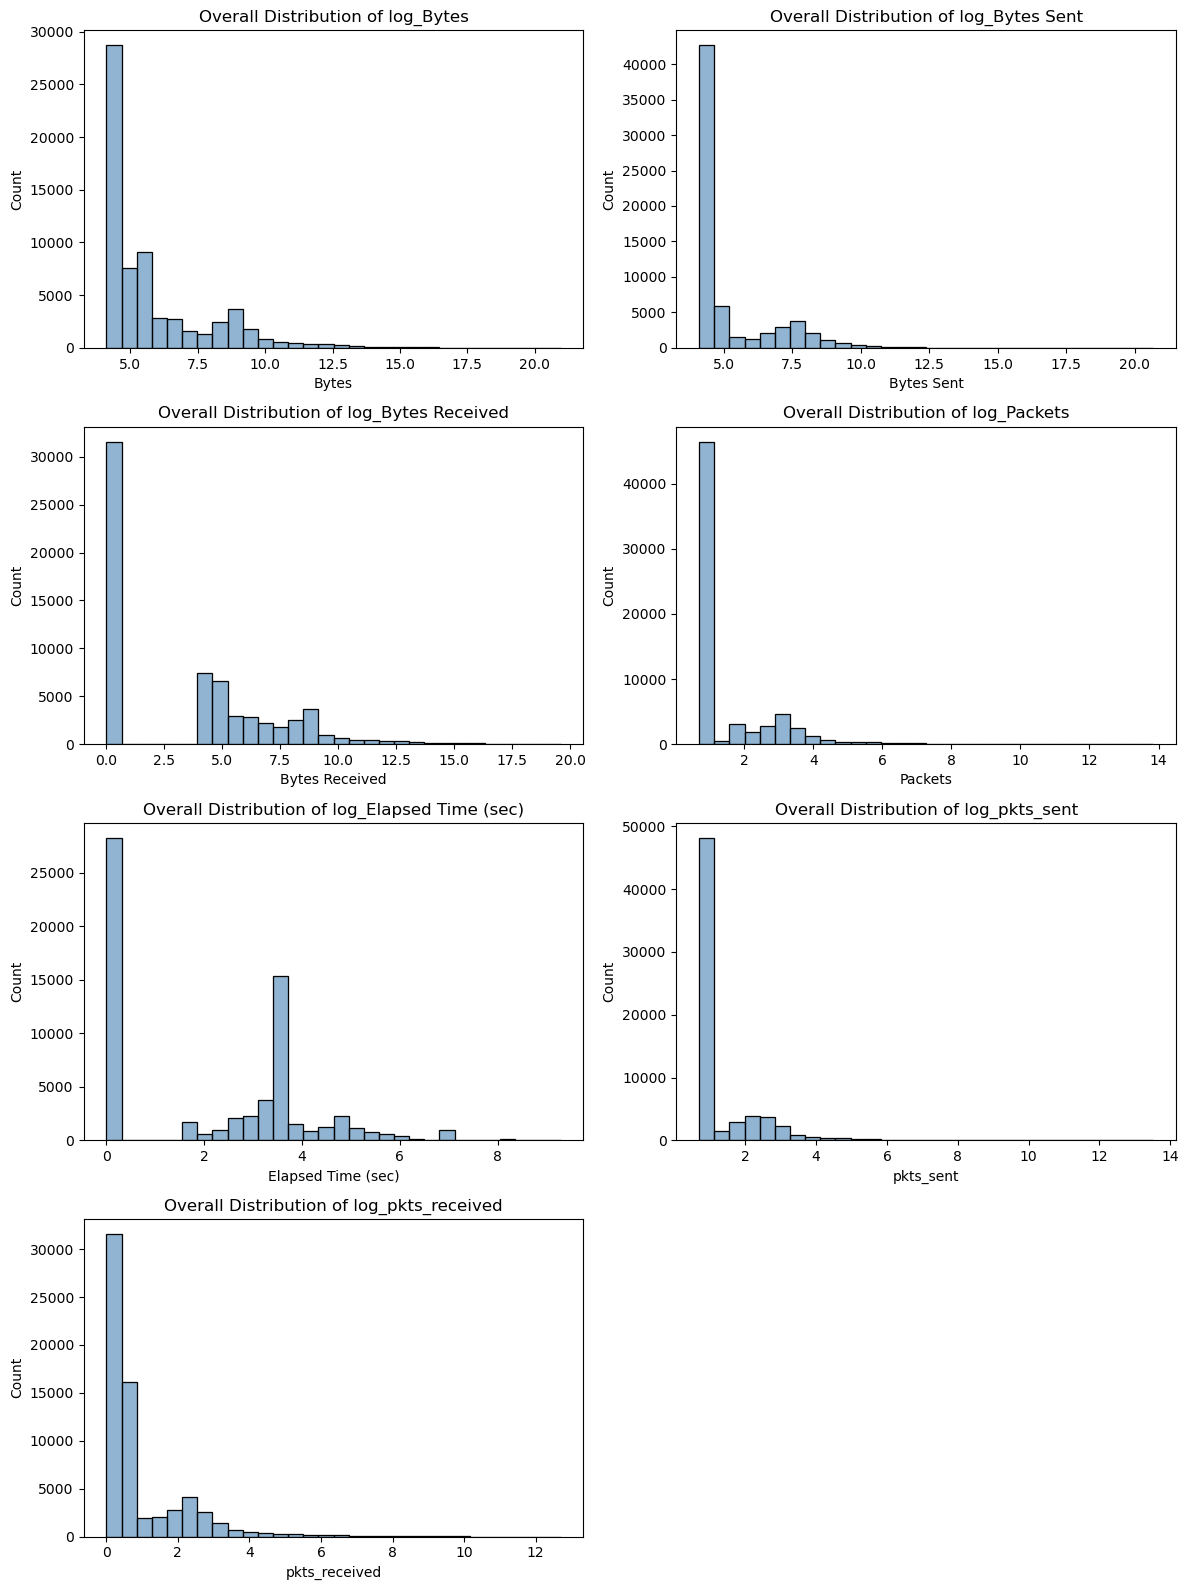

In [18]:
# Make a copy and log-transform numeric columns
data_logged = data_grouped.copy()
numeric_cols = data_logged.select_dtypes(include=['int64', 'float64']).columns

# Apply log(1+x) transform to avoid issues with 0
for col in numeric_cols:
    data_logged[f'log_{col}'] = np.log1p(data_logged[col])

# Prepare for plotting
log_cols = [f'log_{col}' for col in numeric_cols]
n_cols = 2
n_rows = int(np.ceil(len(log_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

# Plot each histogram
for i, col in enumerate(log_cols):
    ax = axes[i]
    sns.histplot(data=data_logged, x=col, bins=30, stat='count',
                 color='steelblue', alpha=0.6, ax=ax)
    ax.set_title(f"Overall Distribution of {col}")
    ax.set_xlabel(col.replace('log_', ''))
    ax.set_ylabel("Count")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

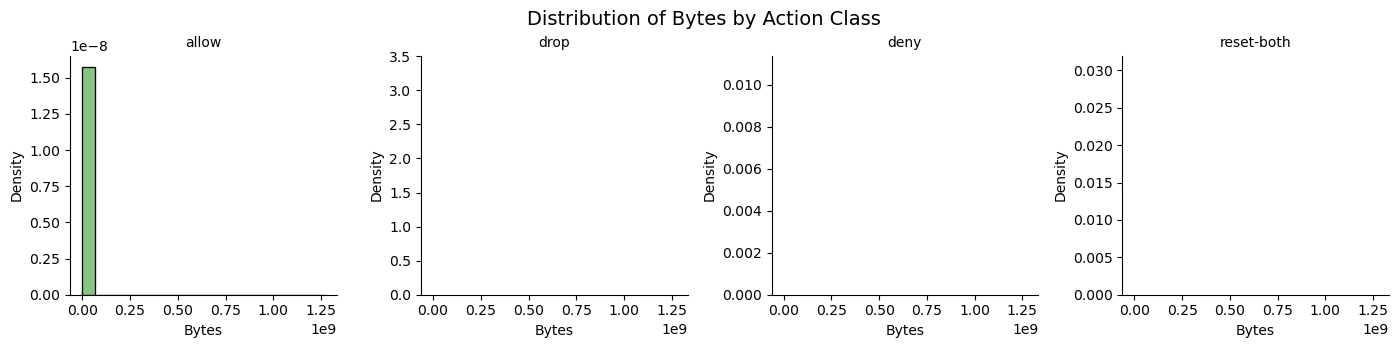

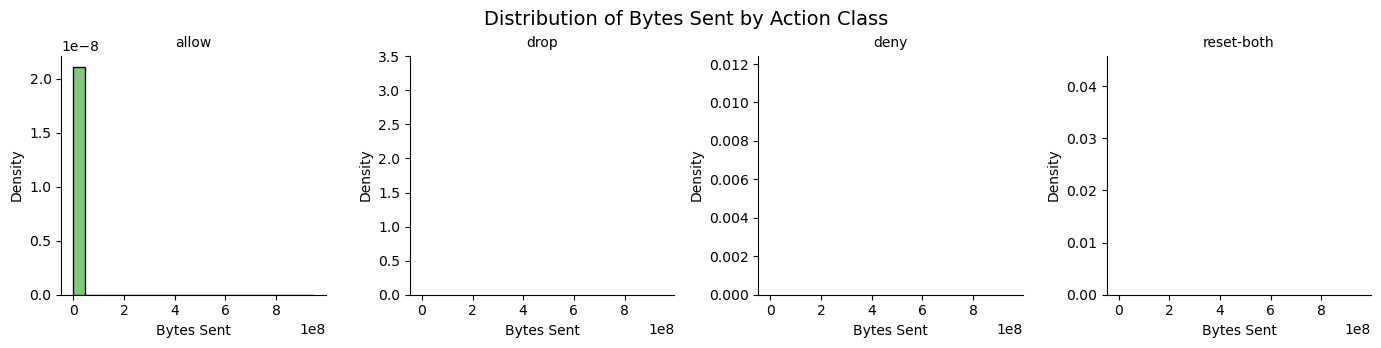

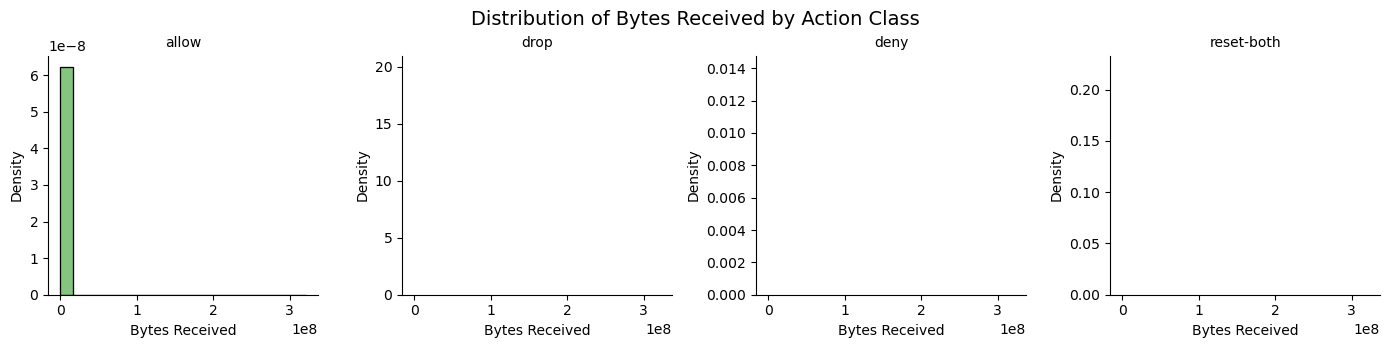

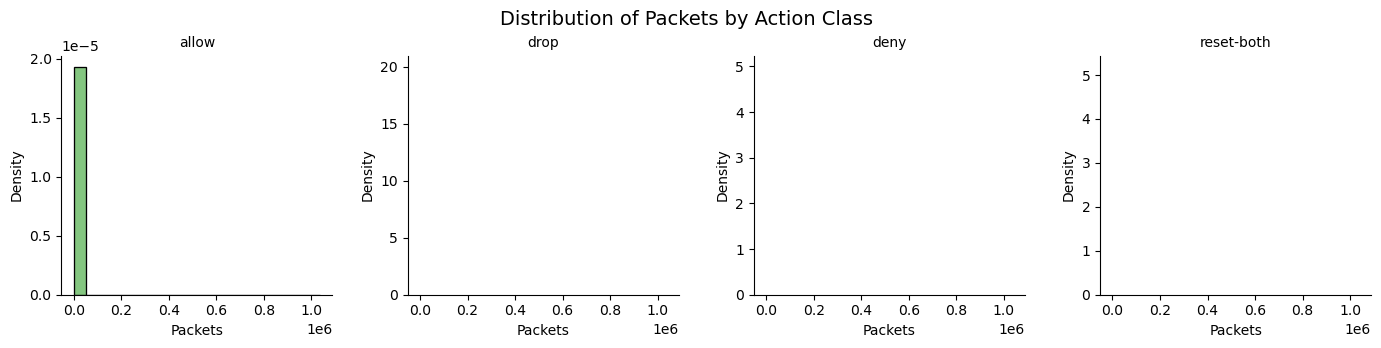

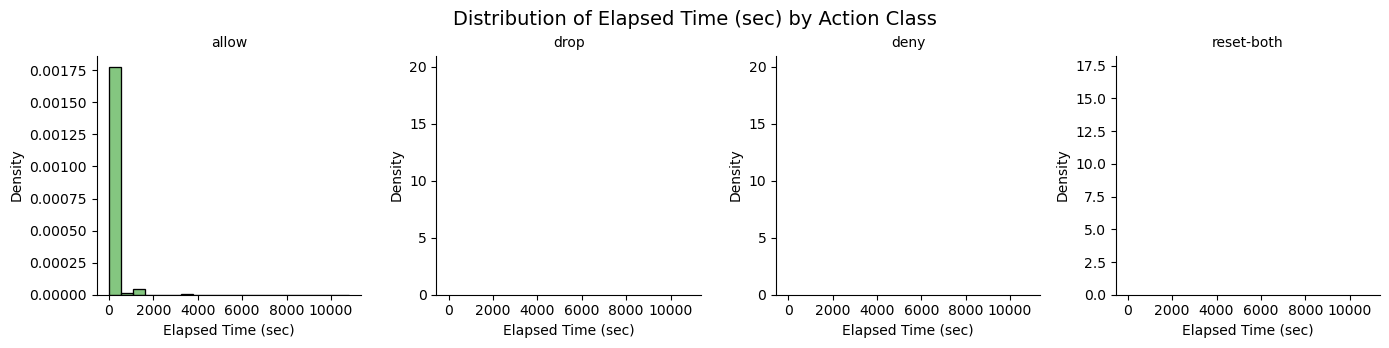

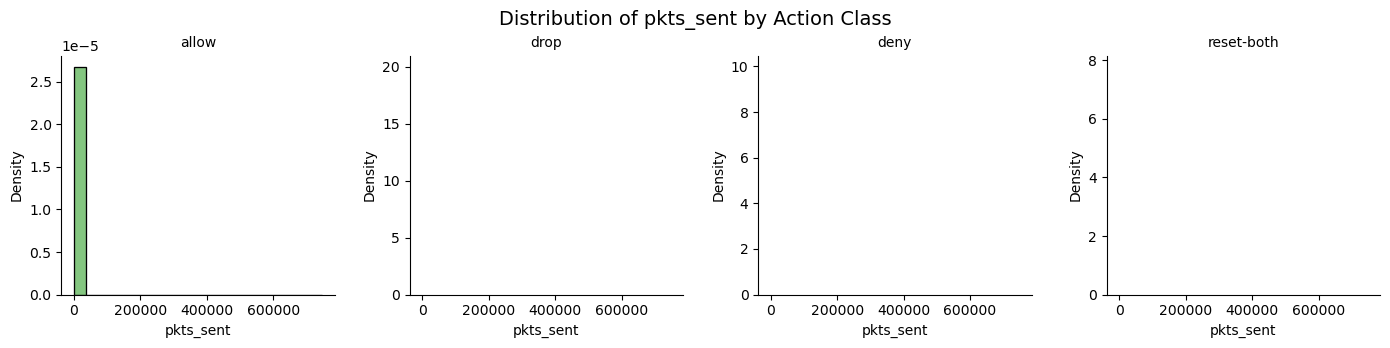

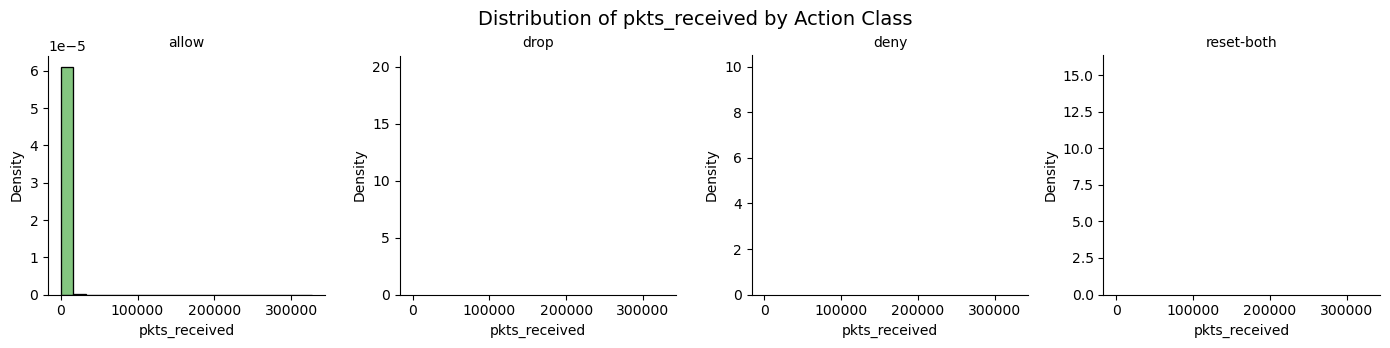

In [19]:
# Plot distributions of numeric features by action class

# List of numeric columns
numeric_cols = data_grouped.select_dtypes(include=['int64']).columns

palette = sns.color_palette("Paired", n_colors=4)[::-1]
action_order = ['allow', 'drop', 'deny', 'reset-both']

# Optional: convert 'Action' to ordered categorical
data_grouped['Action'] = pd.Categorical(data_grouped['Action'], categories=action_order, ordered=True)

# Plot each numeric column
for col in numeric_cols:
    g = sns.FacetGrid(
        data_grouped,
        col='Action',
        hue='Action',  
        hue_order=action_order,
        palette=palette,
        col_wrap=4,
        sharex=True,
        sharey=False,
        height=3.5
    )

    g.map(sns.histplot, col, bins=20, stat='density', alpha=0.6)
    g.set_titles(col_template="{col_name}")
    g.fig.subplots_adjust(top=0.85)
    g.fig.suptitle(f"Distribution of {col} by Action Class", fontsize=14)

    plt.show()

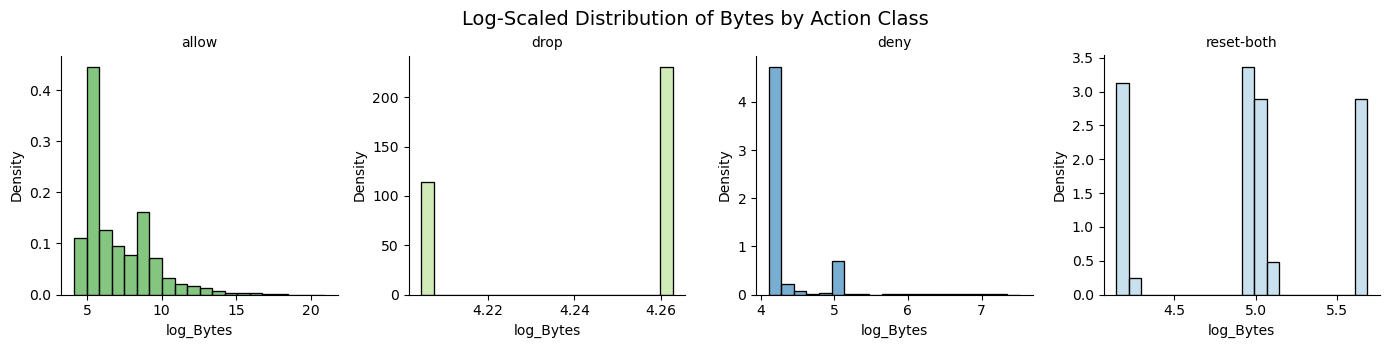

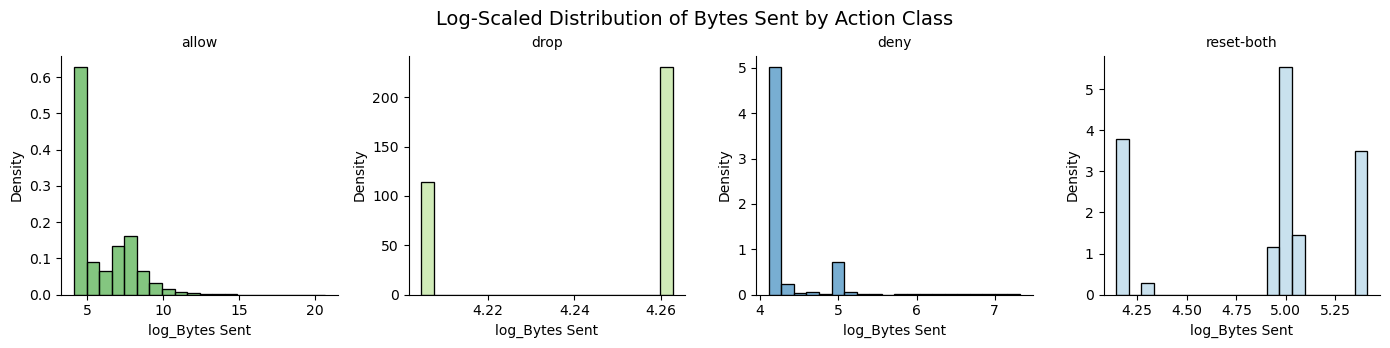

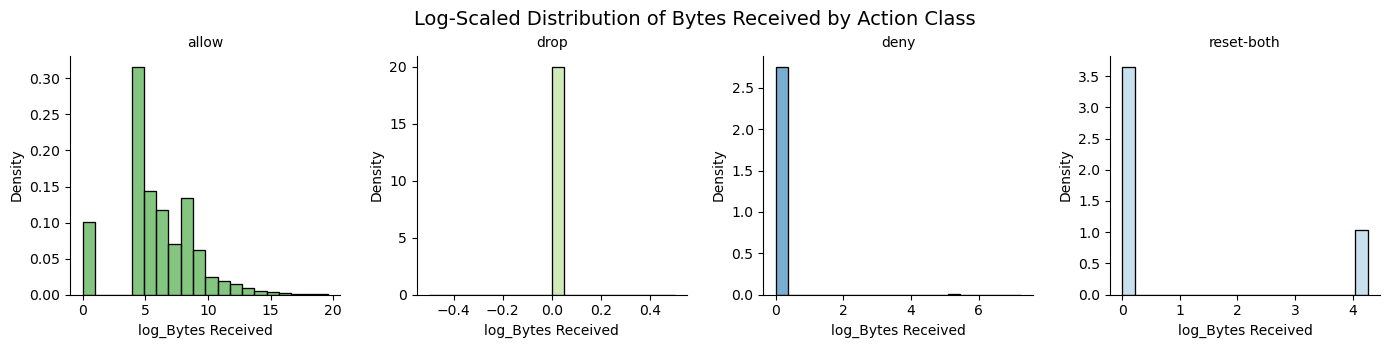

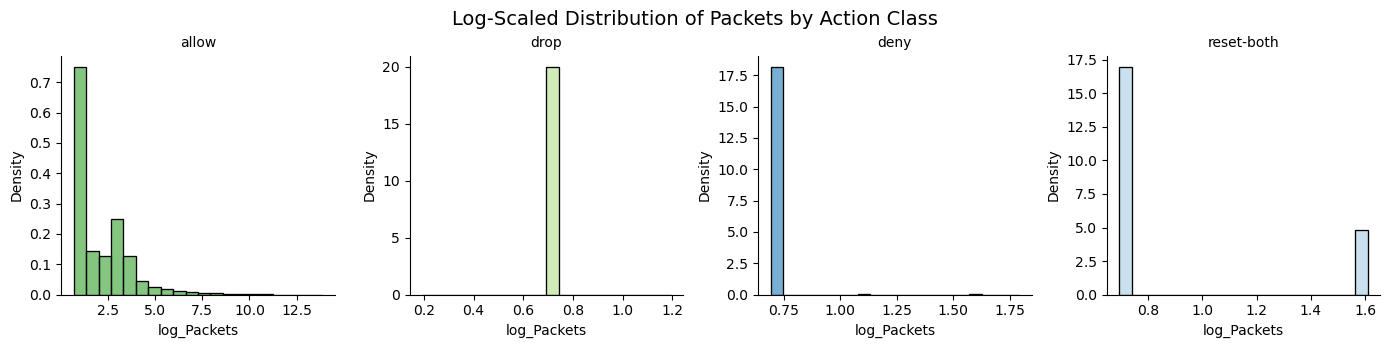

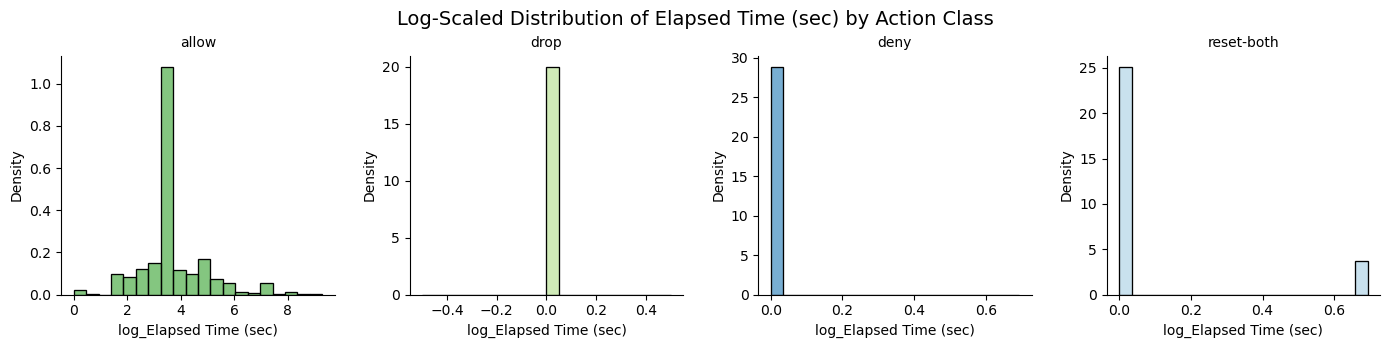

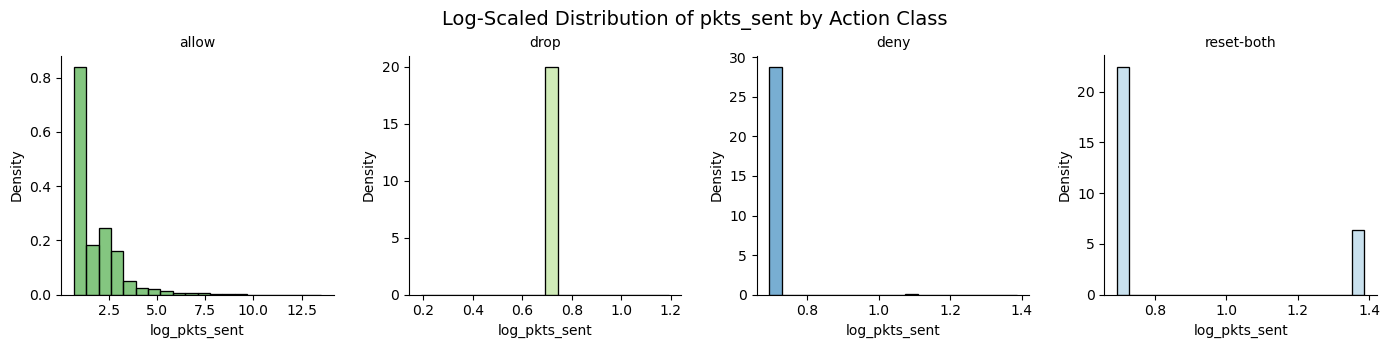

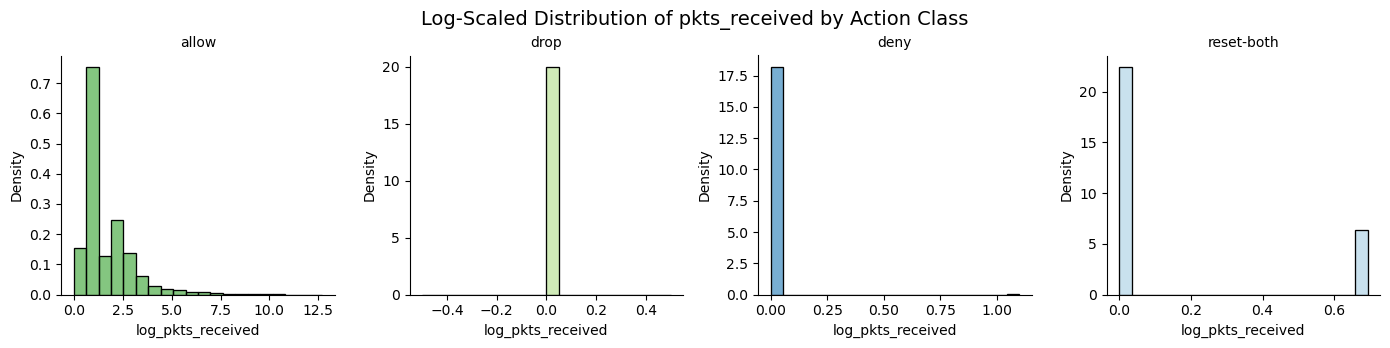

In [20]:
# Plot distributions of log-transformed numeric features by action class

# List of numeric columns
numeric_cols = data_grouped.select_dtypes(include=['int64']).columns

palette = sns.color_palette("Paired", n_colors=4)[::-1]
action_order = ['allow', 'drop', 'deny', 'reset-both']

# Optional: convert 'Action' to ordered categorical
data_grouped['Action'] = pd.Categorical(data_grouped['Action'], categories=action_order, ordered=True)

# Plot each numeric column
for col in numeric_cols:
    log_col = f'log_{col}'
    g = sns.FacetGrid(
        data_logged,
        col='Action',
        hue='Action',
        hue_order=action_order,
        palette=palette,
        col_wrap=4,
        sharex=False,
        sharey=False,
        height=3.5
    )

    g.map(sns.histplot, log_col, bins=20, stat='density', alpha=0.6)
    g.set_titles(col_template="{col_name}")
    g.fig.subplots_adjust(top=0.85)
    g.fig.suptitle(f"Log-Scaled Distribution of {col} by Action Class", fontsize=14)
    plt.show()

The data are heavily skewed, even after log transforming. I will try log transforming and then scaling for modeling.

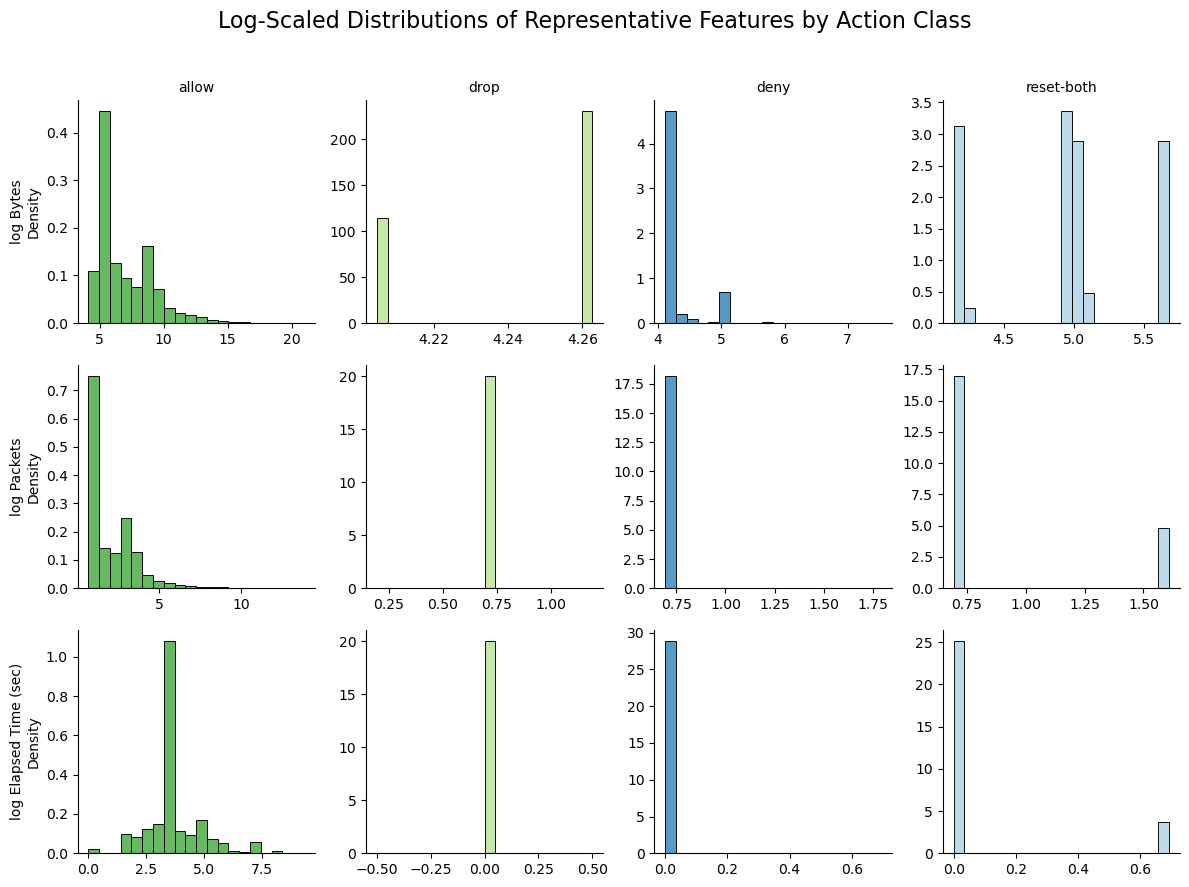

In [21]:
# Plot distributions of log-transformed numeric features by action class

cols_to_plot = ['Bytes', 'Packets', 'Elapsed Time (sec)']
log_cols = [f'log_{col}' for col in cols_to_plot]
action_order = ['allow', 'drop', 'deny', 'reset-both']
palette = sns.color_palette("Paired", n_colors=4)[::-1]

# Ensure 'Action' is categorical and ordered
data_logged['Action'] = pd.Categorical(data_logged['Action'], categories=action_order, ordered=True)

# Set up grid: 3 features × 4 action classes
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 9), sharex=False, sharey=False)

for row_idx, log_col in enumerate(log_cols):
    for col_idx, action in enumerate(action_order):
        ax = axes[row_idx, col_idx]
        subset = data_logged[data_logged['Action'] == action]
        sns.histplot(
            subset[log_col],
            bins=20,
            stat='density',
            ax=ax,
            color=palette[col_idx]
        )

        # Titles and axis labels
        if row_idx == 0:
            ax.set_title(action, fontsize=10)
        if col_idx == 0:
            ax.set_ylabel(f"log {cols_to_plot[row_idx]}\nDensity", fontsize=10)
        else:
            ax.set_ylabel('')
        ax.set_xlabel('')

        # Remove top and right spines only
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Optional: slightly bolder left/bottom spines for clarity
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)
        
# Final layout
plt.suptitle("Log-Scaled Distributions of Representative Features by Action Class", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Preprocessing: Split X and y, define log transformer, scaler, and encoder

In [22]:
data_grouped.columns

Index(['Source Port', 'Destination Port', 'NAT Source Port',
       'NAT Destination Port', 'Action', 'Bytes', 'Bytes Sent',
       'Bytes Received', 'Packets', 'Elapsed Time (sec)', 'pkts_sent',
       'pkts_received'],
      dtype='object')

In [23]:
X = data_grouped.drop(columns='Action')
y = data_grouped['Action']

In [24]:
# Define preprocessing pipeline
numeric_cols = X.select_dtypes(include=['int64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Safe way to ensure all categorical values are treated as strings
X[categorical_cols] = X[categorical_cols].astype(str)

# Preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('log', FunctionTransformer(np.log1p, validate=True)),
        ('scale', StandardScaler()) # I probably should've used RobustScaler because of the skewness and probably outliers?
    ]), numeric_cols),
    
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

### Build two SVM models: LinearSVC and SVC with RBF kernel trick

In [25]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for C in np.logspace(-6, 6, 20):
    start = time.perf_counter()
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('clf', LinearSVC(
            C=C,
            penalty='l2',
            loss='squared_hinge',
            class_weight='balanced',
            max_iter=25000
        ))
    ])
    scores = cross_val_score(pipeline, X, y, cv=kf, scoring='accuracy')
    print(f"C = {C:.2e}, Accuracy = {scores.mean():.5f} ± {scores.std():.6f}, CV time: {(time.perf_counter() - start):.2f} secs")


C = 1.00e-06, Accuracy = 0.95526 ± 0.001460, CV time: 0.57 secs
C = 4.28e-06, Accuracy = 0.97282 ± 0.001548, CV time: 0.60 secs
C = 1.83e-05, Accuracy = 0.99300 ± 0.000574, CV time: 0.68 secs
C = 7.85e-05, Accuracy = 0.99617 ± 0.000257, CV time: 0.72 secs
C = 3.36e-04, Accuracy = 0.99626 ± 0.000153, CV time: 0.76 secs
C = 1.44e-03, Accuracy = 0.99667 ± 0.000124, CV time: 0.82 secs
C = 6.16e-03, Accuracy = 0.99739 ± 0.000189, CV time: 0.90 secs
C = 2.64e-02, Accuracy = 0.99753 ± 0.000157, CV time: 1.05 secs
C = 1.13e-01, Accuracy = 0.99794 ± 0.000097, CV time: 1.14 secs
C = 4.83e-01, Accuracy = 0.99811 ± 0.000195, CV time: 1.37 secs
C = 2.07e+00, Accuracy = 0.99812 ± 0.000157, CV time: 1.72 secs
C = 8.86e+00, Accuracy = 0.99809 ± 0.000136, CV time: 4.07 secs
C = 3.79e+01, Accuracy = 0.99809 ± 0.000136, CV time: 11.41 secs
C = 1.62e+02, Accuracy = 0.99812 ± 0.000157, CV time: 27.57 secs
C = 6.95e+02, Accuracy = 0.99809 ± 0.000174, CV time: 4.54 secs
C = 2.98e+03, Accuracy = 0.99811 ± 0.0

For optimal C, I will choose: C = 2.07e+00, Accuracy = 0.99812 ± 0.000157, CV time: 1.72 secs.

A few other higher C values are essentially the same, taking standard deviation into account. But this has higher regularization and takes less time.

I don't think it is necessary to fine tune, as many values of C achieve nearly the same accuracy.

Transformed input shape: (65532, 903)
Per-fold input shape: (52425.6, 903)
CV time: 1.79 seconds.

CV time (mean per fold): 0.36 seconds.

Accuracy: 0.99811

Classification Report:
              precision    recall  f1-score   support

       allow     0.9999    0.9992    0.9995     37640
        deny     0.9971    0.9946    0.9959     14987
        drop     0.9969    1.0000    0.9984     12851
  reset-both     0.5385    0.7778    0.6364        54

    accuracy                         0.9981     65532
   macro avg     0.8831    0.9429    0.9075     65532
weighted avg     0.9983    0.9981    0.9982     65532


Confusion Matrix:
[[37609    31     0     0]
 [    5 14906    40    36]
 [    0     0 12851     0]
 [    0    12     0    42]]


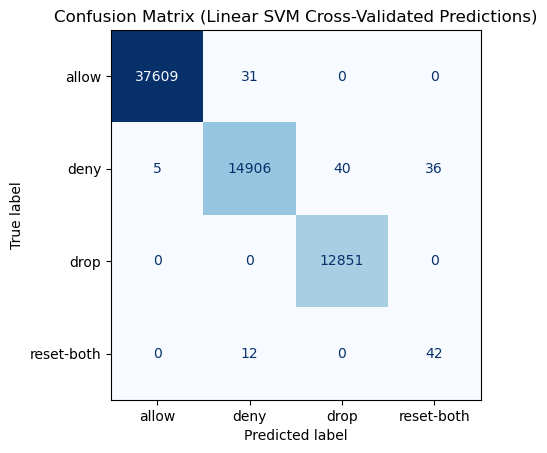

In [26]:
# Fit and transform once to inspect the input size the model will see
X_transformed = preprocessor.fit_transform(X)
print(f"Transformed input shape: {X_transformed.shape}") 
print(f"Per-fold input shape: {(X_transformed.shape[0] / 5 * 4, X_transformed.shape[1])}") 

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

start = time.perf_counter()
lin_svm_pipeline = Pipeline([
    ('preprocessing', preprocessor), 
    ('clf', LinearSVC(
        C=2.07,
        penalty='l2',
        loss='squared_hinge',
        class_weight='balanced',
        max_iter=25000
        ))
    ])

# Get cross-validated predictions (same length as y)
y_pred_linsvm = cross_val_predict(lin_svm_pipeline, X, y, cv=kf)

total_time = time.perf_counter() - start
mean_time = total_time / kf.get_n_splits()
print(f'CV time: {total_time:.2f} seconds.\n')
print(f'CV time (mean per fold): {mean_time:.2f} seconds.\n')


# Metrics
print(f"Accuracy: {accuracy_score(y, y_pred_linsvm):.5f}")

print("\nClassification Report:")
print(classification_report(y, y_pred_linsvm, digits=4))

cm_linsvm = confusion_matrix(y, y_pred_linsvm)
print("\nConfusion Matrix:")
print(cm_linsvm)

# Get class labels
labels = np.unique(y)

# Create ConfusionMatrixDisplay with labels and color map
disp = ConfusionMatrixDisplay(confusion_matrix=cm_linsvm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, colorbar=False)
plt.title("Confusion Matrix (Linear SVM Cross-Validated Predictions)")
plt.show()


In [27]:
# Do an 80/20 train test split instead of CV for SVM models
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=True, stratify=y, random_state=SEED)

In [28]:
# SVC with RBF Kernel trick pipeline, tuning C (lowest C = most regularization)
for C in np.logspace(-6, 6, 20):
    start = time.perf_counter()
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('clf', SVC(
            C=C,
            kernel='rbf',
            cache_size=400,  # default = 200
            class_weight='balanced'
        ))
    ])

    pipeline.fit(X_train, y_train)
    y_preds = pipeline.predict(X_test)
    print(f'C={C:.2e}, Accuracy={accuracy_score(y_test, y_preds):.5f}, Time={(time.perf_counter() - start):.2f} secs')

C=1.00e-06, Accuracy=0.22873, Time=88.93 secs
C=4.28e-06, Accuracy=0.57435, Time=87.64 secs
C=1.83e-05, Accuracy=0.22873, Time=88.32 secs
C=7.85e-05, Accuracy=0.22873, Time=88.34 secs
C=3.36e-04, Accuracy=0.74479, Time=62.03 secs
C=1.44e-03, Accuracy=0.98665, Time=26.32 secs
C=6.16e-03, Accuracy=0.98543, Time=10.26 secs
C=2.64e-02, Accuracy=0.98772, Time=3.97 secs
C=1.13e-01, Accuracy=0.99130, Time=1.88 secs
C=4.83e-01, Accuracy=0.99168, Time=1.33 secs
C=2.07e+00, Accuracy=0.99214, Time=1.04 secs
C=8.86e+00, Accuracy=0.99237, Time=0.96 secs
C=3.79e+01, Accuracy=0.99245, Time=1.02 secs
C=1.62e+02, Accuracy=0.99268, Time=1.03 secs
C=6.95e+02, Accuracy=0.99275, Time=1.02 secs
C=2.98e+03, Accuracy=0.99275, Time=1.01 secs
C=1.27e+04, Accuracy=0.99351, Time=1.03 secs
C=5.46e+04, Accuracy=0.99458, Time=0.89 secs
C=2.34e+05, Accuracy=0.99458, Time=1.15 secs
C=1.00e+06, Accuracy=0.99458, Time=1.34 secs


For optimal C, I will choose: C=5.46e+04, Accuracy=0.99458, Time=0.81 secs.

A few other higher C values are essentially the same, but this has higher regularization and takes less time.

I don't think it is necessary to fine tune, as many values of C achieve nearly the same accuracy.

Input shape to classifier (after preprocessing): (52425, 903)
13107 13107
Time:0.87 secs
Accuracy: 0.99458

Classification Report:
              precision    recall  f1-score   support

       allow     1.0000    0.9996    0.9998      7528
        deny     0.9980    0.9783    0.9880      2998
        drop     0.9965    1.0000    0.9983      2570
  reset-both     0.1250    0.7273    0.2133        11

    accuracy                         0.9946     13107
   macro avg     0.7799    0.9263    0.7999     13107
weighted avg     0.9981    0.9946    0.9961     13107


Confusion Matrix:
[[7525    3    0    0]
 [   0 2933    9   56]
 [   0    0 2570    0]
 [   0    3    0    8]]


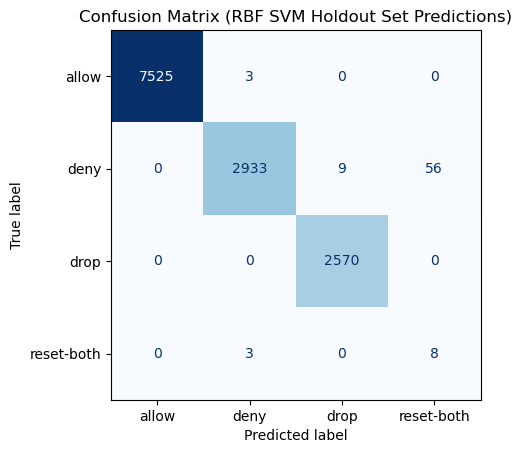

In [29]:
rbf_svm_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('clf', SVC(
        C=5.46e+04,
        kernel='rbf',
        cache_size=400,
        class_weight='balanced'
        ))
    ])

# Check transformed input shape
X_train_transformed = rbf_svm_pipeline.named_steps['preprocessing'].fit_transform(X_train)
print(f"Input shape to classifier (after preprocessing): {X_train_transformed.shape}")

start = time.perf_counter()
rbf_svm_pipeline.fit(X_train, y_train)
y_pred_rbfsvm = rbf_svm_pipeline.predict(X_test)

print(len(y_test), len(y_pred_rbfsvm))

# Metrics
print(f'Time:{(time.perf_counter() - start):.2f} secs')

print(f"Accuracy: {accuracy_score(y_test, y_pred_rbfsvm):.5f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rbfsvm, digits=4))

cm_rbfsvm = confusion_matrix(y_test, y_pred_rbfsvm)
print("\nConfusion Matrix:")
print(cm_rbfsvm)

# Get class labels
labels = np.unique(y)

# Create ConfusionMatrixDisplay with labels and color map
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rbfsvm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, colorbar=False)
plt.title("Confusion Matrix (RBF SVM Holdout Set Predictions)")
plt.show()

### Build a logistic regression model using SGD

class sklearn.linear_model.SGDClassifier(loss='hinge', *, penalty='l2', alpha=0.0001, l1_ratio=0.15, fit_intercept=True, max_iter=1000, tol=0.001, shuffle=True, verbose=0, epsilon=0.1, n_jobs=None, random_state=None, learning_rate='optimal', eta0=0.0, power_t=0.5, early_stopping=False, validation_fraction=0.1, n_iter_no_change=5, class_weight=None, warm_start=False, average=False)

- loss="log_loss"
- early_stopping=True
- random_state=SEED
- class_weight='balanced'
- validation_fraction=0.2 (% of training data to estimate loss, same as 80/20 split)
- defaults:
  - penalty='l2'
  - max_iter=1000 (# of epochs)
  - shuffle=True
  - learning_rate='optimal'
  - eta0=0.0
  - n_iter_no_change=5 (5-20) (early stopping)
- tune:
  - alpha=0.0001

In [30]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Coarse tune alpha
for alpha in [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]:
    start = time.perf_counter()
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('clf', SGDClassifier(
            alpha=alpha,
            penalty='l2',
            loss='log_loss',
            early_stopping=True,       # Important for SGD!
            n_iter_no_change=10,       # early stopping criterion
            max_iter=1000,             # default 1000 is probably fine
            validation_fraction=0.2, 
            class_weight='balanced',   # % of training data to estimate loss (in the CV training fold here)
            shuffle=True, 
            random_state=SEED
        ))
    ])
    scores = cross_val_score(pipeline, X, y, cv=kf, scoring='accuracy')
    print(f"alpha = {alpha:.2e}, Accuracy = {scores.mean():.5f} ± {scores.std():.6f}, CV time: {(time.perf_counter() - start):.2f} secs")


alpha = 1.00e-06, Accuracy = 0.98729 ± 0.001983, CV time: 0.96 secs
alpha = 1.00e-05, Accuracy = 0.98872 ± 0.004189, CV time: 1.11 secs
alpha = 1.00e-04, Accuracy = 0.99652 ± 0.000887, CV time: 1.11 secs
alpha = 1.00e-03, Accuracy = 0.99580 ± 0.001070, CV time: 1.07 secs
alpha = 1.00e-02, Accuracy = 0.98730 ± 0.013381, CV time: 1.06 secs
alpha = 1.00e-01, Accuracy = 0.98273 ± 0.017814, CV time: 1.04 secs
alpha = 1.00e+00, Accuracy = 0.95500 ± 0.001292, CV time: 1.04 secs


In [31]:
# Fine tune alpha
best_alpha = 1.00e-04
for alpha in np.logspace(np.log10(best_alpha / 10), np.log10(best_alpha * 10), 10):
    start = time.perf_counter()
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('clf', SGDClassifier(
            alpha=alpha,
            penalty='l2',
            loss='log_loss',
            early_stopping=True,       # Important for SGD!
            n_iter_no_change=10,       # early stopping criterion
            max_iter=1000,             # default 1000 is probably fine
            validation_fraction=0.2, 
            class_weight='balanced',   # % of training data to estimate loss (in the CV training fold here)
            shuffle=True, 
            random_state=SEED,
            verbose=0
        ))
    ])
    scores = cross_val_score(pipeline, X, y, cv=kf, scoring='accuracy')
    print(f"alpha = {alpha:.2e}, Accuracy = {scores.mean():.5f} ± {scores.std():.6f}, CV time: {(time.perf_counter() - start):.2f} secs")


alpha = 1.00e-05, Accuracy = 0.98872 ± 0.004189, CV time: 1.05 secs
alpha = 1.67e-05, Accuracy = 0.99290 ± 0.003524, CV time: 1.08 secs
alpha = 2.78e-05, Accuracy = 0.99615 ± 0.000993, CV time: 1.06 secs
alpha = 4.64e-05, Accuracy = 0.99419 ± 0.003166, CV time: 1.13 secs
alpha = 7.74e-05, Accuracy = 0.99539 ± 0.001889, CV time: 1.15 secs
alpha = 1.29e-04, Accuracy = 0.99643 ± 0.001172, CV time: 1.17 secs
alpha = 2.15e-04, Accuracy = 0.99664 ± 0.000410, CV time: 1.13 secs
alpha = 3.59e-04, Accuracy = 0.99637 ± 0.000787, CV time: 1.11 secs
alpha = 5.99e-04, Accuracy = 0.99608 ± 0.000942, CV time: 1.09 secs
alpha = 1.00e-03, Accuracy = 0.99580 ± 0.001070, CV time: 0.97 secs


For optimal alpha, I will choose: alpha = 2.15e-04, Accuracy = 0.99664 ± 0.000410, CV time: 0.79 secs

It is close to the default, has high mean accuracy and low standard deviation.

In [32]:
# Try smaller tolerances to aim for ~20 epochs after early stopping
for tol in [1e-3, 1e-4, 1e-5]:
    start = time.perf_counter()
    epochs = []
    accuracies = []
    
    for train_idx, test_idx in kf.split(X, y):
        X_train_sgd, X_test_sgd = X.iloc[train_idx], X.iloc[test_idx]
        y_train_sgd, y_test_sgd = y.iloc[train_idx], y.iloc[test_idx]


        pipeline = Pipeline([
            ('preprocessing', preprocessor),
            ('clf', SGDClassifier(
                alpha=2.15e-04,
                penalty='l2',
                tol=tol,
                loss='log_loss',
                early_stopping=True,
                n_iter_no_change=15,
                max_iter=1000,
                validation_fraction=0.2,
                class_weight='balanced',
                shuffle=True,
                random_state=SEED
            ))
        ])

        pipeline.fit(X_train_sgd, y_train_sgd)
        y_pred = pipeline.predict(X_test_sgd)
        acc = accuracy_score(y_test_sgd, y_pred)
        accuracies.append(acc)

        # Access the number of epochs from the classifier
        n_iter = pipeline.named_steps['clf'].n_iter_
        epochs.append(n_iter)

    print(f"tol = {tol:.2e}, Accuracy = {np.mean(accuracies):.5f} ± {np.std(accuracies):.6f}, "
          f"Epochs: {epochs}, Mean epochs: {np.mean(epochs):.1f}, Time: {(time.perf_counter() - start):.2f}s")


tol = 1.00e-03, Accuracy = 0.99612 ± 0.000935, Epochs: [16, 16, 16, 16, 16], Mean epochs: 16.0, Time: 1.20s
tol = 1.00e-04, Accuracy = 0.99570 ± 0.000914, Epochs: [16, 17, 16, 17, 16], Mean epochs: 16.4, Time: 1.19s
tol = 1.00e-05, Accuracy = 0.99571 ± 0.000930, Epochs: [18, 17, 16, 17, 16], Mean epochs: 16.8, Time: 1.31s


In [33]:
# Try learning rate adaptive (so need to tune eta) to aim for ~20 epochs after early stopping
for eta0 in [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]:
    start = time.perf_counter()
    epochs = []
    accuracies = []
    
    for train_idx, test_idx in kf.split(X, y):
        X_train_sgd, X_test_sgd = X.iloc[train_idx], X.iloc[test_idx]
        y_train_sgd, y_test_sgd = y.iloc[train_idx], y.iloc[test_idx]


        pipeline = Pipeline([
            ('preprocessing', preprocessor),
            ('clf', SGDClassifier(
                alpha=2.15e-04,
                penalty='l2',
                tol=0.001,          # default
                learning_rate='adaptive',
                eta0=eta0,
                loss='log_loss',
                early_stopping=True,
                n_iter_no_change=15,
                max_iter=1000,
                validation_fraction=0.2,
                class_weight='balanced',
                shuffle=True,
                random_state=SEED,
                verbose=0
            ))
        ])

        pipeline.fit(X_train_sgd, y_train_sgd)
        y_pred = pipeline.predict(X_test_sgd)
        acc = accuracy_score(y_test_sgd, y_pred)
        accuracies.append(acc)

        # Access the number of epochs from the classifier
        n_iter = pipeline.named_steps['clf'].n_iter_
        epochs.append(n_iter)

    print(f"eta0 = {eta0:.2e}, Accuracy = {np.mean(accuracies):.5f} ± {np.std(accuracies):.6f}, "
          f"Epochs: {epochs}, Mean epochs: {np.mean(epochs):.1f}, Time: {(time.perf_counter() - start):.2f}s")

eta0 = 1.00e-05, Accuracy = 0.99194 ± 0.000568, Epochs: [62, 62, 61, 72, 63], Mean epochs: 64.0, Time: 2.77s
eta0 = 1.00e-04, Accuracy = 0.99591 ± 0.000133, Epochs: [75, 74, 74, 74, 74], Mean epochs: 74.2, Time: 3.16s
eta0 = 1.00e-03, Accuracy = 0.99646 ± 0.000271, Epochs: [94, 94, 94, 94, 94], Mean epochs: 94.0, Time: 4.36s
eta0 = 1.00e-02, Accuracy = 0.99684 ± 0.000224, Epochs: [106, 106, 106, 106, 106], Mean epochs: 106.0, Time: 5.11s
eta0 = 1.00e-01, Accuracy = 0.99687 ± 0.000216, Epochs: [136, 136, 136, 136, 136], Mean epochs: 136.0, Time: 6.22s


alpha = 2.15e-04, Accuracy = 0.99664 ± 0.000410, CV time: 0.79 secs

I used learning_rate='optimal' with early stopping and observed convergence in 6–16 epochs, depending on my early stopping criteria. Despite short training, accuracy and loss stabilized early, and additional training with adaptive or reduced tol increased epochs but didn't improve validation accuracy. Model generalization appears stable across folds.

In [34]:
# --- Models ---
model_optimal = Pipeline([
    ('preprocessing', preprocessor),
    ('clf', SGDClassifier(
        loss='log_loss',
        alpha=2.15e-04,
        learning_rate='optimal',
        early_stopping=True,
        n_iter_no_change=10,
        tol=1e-3,
        max_iter=1000,
        validation_fraction=0.2,
        class_weight='balanced',
        random_state=SEED
    ))
])

model_adaptive = Pipeline([
    ('preprocessing', preprocessor),
    ('clf', SGDClassifier(
        loss='log_loss',
        alpha=2.15e-04,
        learning_rate='adaptive',
        eta0=1e-2,
        early_stopping=True,
        n_iter_no_change=10,
        tol=1e-3,
        max_iter=1000,
        validation_fraction=0.2,
        class_weight='balanced',
        random_state=SEED
    ))
])

# --- Evaluation function ---
def evaluate_model_with_metrics(model, X, y, cv):
    log_losses = []
    accuracies = []
    epochs = []
    times = []

    for train_idx, test_idx in cv.split(X, y):
        X_train_sgd, X_test_sgd = X.iloc[train_idx], X.iloc[test_idx]
        y_train_sgd, y_test_sgd = y.iloc[train_idx], y.iloc[test_idx]

        model_clone = clone(model)

        start_time = time.perf_counter()
        model_clone.fit(X_train_sgd, y_train_sgd)
        end_time = time.perf_counter()

        y_pred_proba = model_clone.predict_proba(X_test_sgd)
        y_pred = model_clone.predict(X_test_sgd)

        log_losses.append(log_loss(y_test_sgd, y_pred_proba))
        accuracies.append(accuracy_score(y_test_sgd, y_pred))
        epochs.append(model_clone.named_steps['clf'].n_iter_)
        times.append(end_time - start_time)

    return log_losses, accuracies, epochs, times

# --- Run evaluation ---
losses_opt, accs_opt, epochs_opt, times_opt = evaluate_model_with_metrics(model_optimal, X, y, kf)
losses_adapt, accs_adapt, epochs_adapt, times_adapt = evaluate_model_with_metrics(model_adaptive, X, y, kf)

# --- Report results ---
print(f"Optimal LR:")
print(f"  Log Loss = {np.mean(losses_opt):.5f} ± {np.std(losses_opt):.6f}")
print(f"  Accuracy = {np.mean(accs_opt):.5f} ± {np.std(accs_opt):.6f}")
print(f"  Epochs per fold: {epochs_opt}, Mean = {np.mean(epochs_opt):.1f}")
print(f"  Training time per fold (sec): {np.round(times_opt, 3)}, Mean = {np.mean(times_opt):.3f}s")

print(f"\nAdaptive LR:")
print(f"  Log Loss = {np.mean(losses_adapt):.5f} ± {np.std(losses_adapt):.6f}")
print(f"  Accuracy = {np.mean(accs_adapt):.5f} ± {np.std(accs_adapt):.6f}")
print(f"  Epochs per fold: {epochs_adapt}, Mean = {np.mean(epochs_adapt):.1f}")
print(f"  Training time per fold (sec): {np.round(times_adapt, 3)}, Mean = {np.mean(times_adapt):.3f}s")

Optimal LR:
  Log Loss = 0.03410 ± 0.005509
  Accuracy = 0.99664 ± 0.000410
  Epochs per fold: [11, 11, 11, 11, 11], Mean = 11.0
  Training time per fold (sec): [0.194 0.202 0.204 0.189 0.218], Mean = 0.201s

Adaptive LR:
  Log Loss = 0.04146 ± 0.000580
  Accuracy = 0.99683 ± 0.000229
  Epochs per fold: [71, 71, 71, 71, 71], Mean = 71.0
  Training time per fold (sec): [0.68  0.71  0.71  0.646 0.715], Mean = 0.692s


I compared SGDClassifier using both 'optimal' and 'adaptive' learning rate strategies with early stopping.

- Optimal LR achieved a mean log loss of 0.03410 ± 0.00551, training in just 11 epochs and averaging 0.139s per fold.

- Adaptive LR required 71 epochs and over 4× the training time (0.557s) per fold, yet performed no better in accuracy (0.99683 vs. 0.99664) and showed higher log loss (0.04146).

While I tuned eta0 for adaptive and reduced the tol value to encourage longer training, the accuracy did not improve and, in some cases, decreased slightly. Therefore, we selected the 'optimal' learning rate, which achieves faster convergence, lower loss, and comparable or better accuracy within the early stopping range of 6–16 epochs.

Transformed input shape: (65532, 903)
Per-fold input shape: (52425.6, 903)
CV time: 0.92 seconds.

CV time (mean per fold): 0.18 seconds.

Accuracy: 0.99664

Classification Report:
              precision    recall  f1-score   support

       allow     0.9997    0.9966    0.9982     37640
        deny     0.9916    0.9955    0.9935     14987
        drop     0.9969    1.0000    0.9984     12851
  reset-both     0.4058    0.5185    0.4553        54

    accuracy                         0.9966     65532
   macro avg     0.8485    0.8777    0.8614     65532
weighted avg     0.9968    0.9966    0.9967     65532


Confusion Matrix:
[[37513   101     0    26]
 [   12 14920    40    15]
 [    0     0 12851     0]
 [    0    26     0    28]]


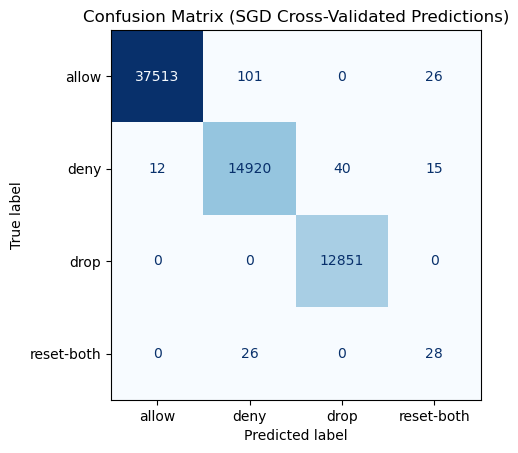

In [35]:
# Final fit and evaluate
# Fit and transform once to inspect the input size the model will see
X_transformed = preprocessor.fit_transform(X)
print(f"Transformed input shape: {X_transformed.shape}") 
print(f"Per-fold input shape: {(X_transformed.shape[0] / 5 * 4, X_transformed.shape[1])}") 

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

start = time.perf_counter()
sgd_pipeline = Pipeline([
    ('preprocessing', preprocessor), 
    ('clf', SGDClassifier(
        loss='log_loss',
        alpha=2.15e-04,
        learning_rate='optimal',
        early_stopping=True,
        n_iter_no_change=10,
        tol=1e-3,
        max_iter=1000,
        validation_fraction=0.2,
        class_weight='balanced',
        random_state=SEED
    ))
])

# Get cross-validated predictions (same length as y)
y_pred_sgd = cross_val_predict(sgd_pipeline, X, y, cv=kf)

total_time = time.perf_counter() - start
mean_time = total_time / kf.get_n_splits()
print(f'CV time: {total_time:.2f} seconds.\n')
print(f'CV time (mean per fold): {mean_time:.2f} seconds.\n')

# Metrics
print(f"Accuracy: {accuracy_score(y, y_pred_sgd):.5f}")

print("\nClassification Report:")
print(classification_report(y, y_pred_sgd, digits=4))

cm_sgd = confusion_matrix(y, y_pred_sgd)
print("\nConfusion Matrix:")
print(cm_sgd)

# Get class labels
labels = np.unique(y)

# Create ConfusionMatrixDisplay with labels and color map
disp = ConfusionMatrixDisplay(confusion_matrix=cm_sgd, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, colorbar=False)
plt.title("Confusion Matrix (SGD Cross-Validated Predictions)")
plt.show()

In [36]:
print(len(y_test), len(y_pred_rbfsvm))

13107 13107


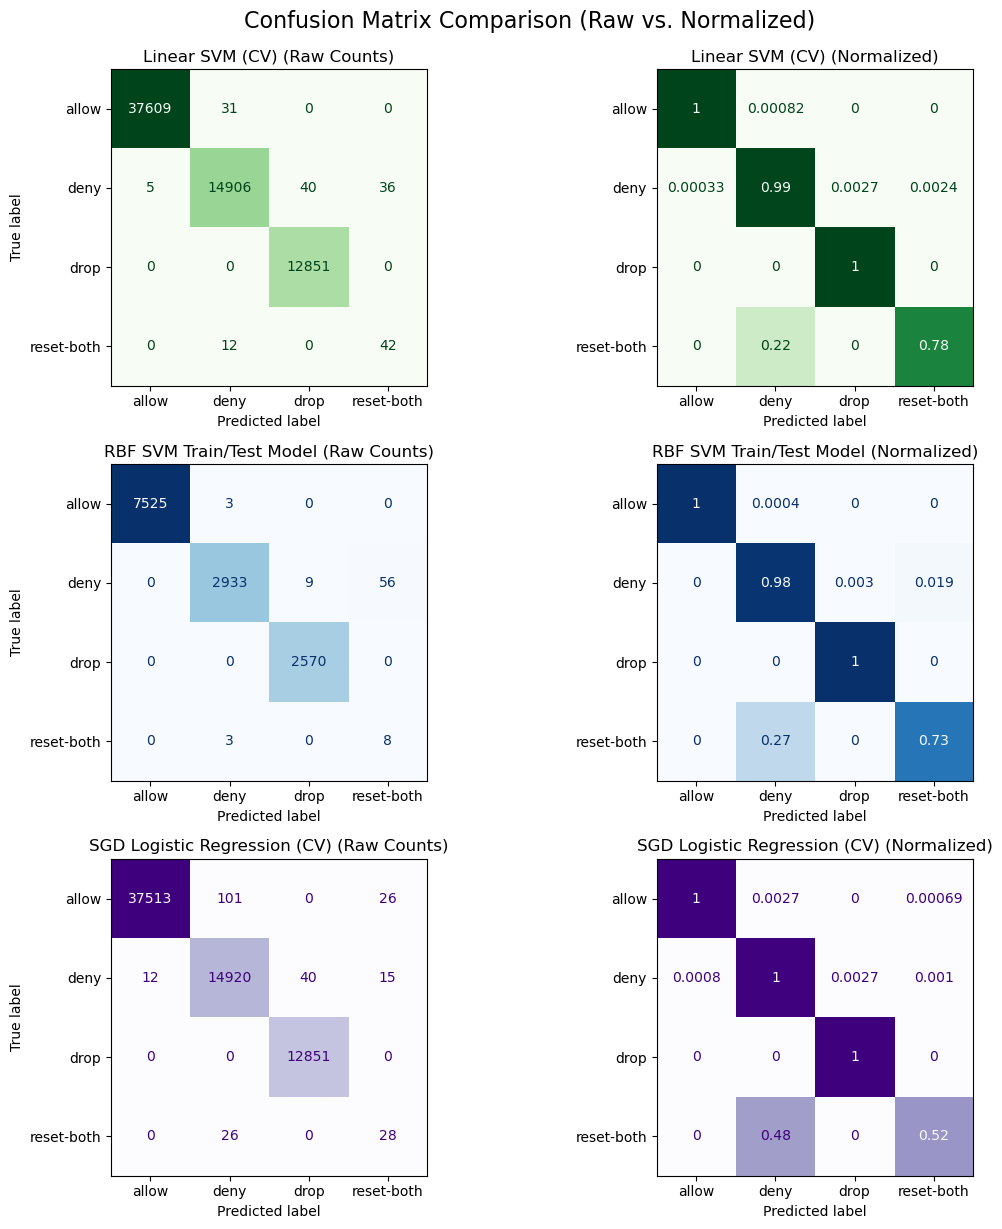

In [37]:
# Class labels (used for consistent axis labels)
labels = np.unique(y)

# Compute raw and normalized confusion matrices
confusion_data = {
    "Linear SVM (CV)": {
        "raw": confusion_matrix(y, y_pred_linsvm, labels=labels),
        "normalized": confusion_matrix(y, y_pred_linsvm, labels=labels, normalize='true')
    },
    "RBF SVM Train/Test Model": {
        "raw": confusion_matrix(y_test, y_pred_rbfsvm, labels=labels),
        "normalized": confusion_matrix(y_test, y_pred_rbfsvm, labels=labels, normalize='true')
    },
    "SGD Logistic Regression (CV)": {
        "raw": confusion_matrix(y, y_pred_sgd, labels=labels),
        "normalized": confusion_matrix(y, y_pred_sgd, labels=labels, normalize='true')
    }
}

model_colormaps = {
    "Linear SVM (CV)": plt.cm.Greens,
    "RBF SVM Train/Test Model": plt.cm.Blues,
    "SGD Logistic Regression (CV)": plt.cm.Purples
}

# Plot raw vs. normalized for each model
n_models = len(confusion_data)
fig, axes = plt.subplots(n_models, 2, figsize=(12, 4 * n_models))

for i, (model_name, cms) in enumerate(confusion_data.items()):
    cmap = model_colormaps[model_name]

    # Raw
    disp_raw = ConfusionMatrixDisplay(confusion_matrix=cms["raw"], display_labels=labels)
    disp_raw.plot(ax=axes[i, 0], cmap=cmap, colorbar=False)
    axes[i, 0].set_title(f"{model_name} (Raw Counts)")

    # Normalized
    disp_norm = ConfusionMatrixDisplay(confusion_matrix=cms["normalized"], display_labels=labels)
    disp_norm.plot(ax=axes[i, 1], cmap=cmap, colorbar=False)
    axes[i, 1].set_title(f"{model_name} (Normalized)")

# Remove redundant y-axis labels in right column
for ax_row in axes:
    ax_row[1].set_ylabel('')  # removes y-axis label from normalized plots

# Turn off gridlines for cleaner look
for ax_row in axes:
    for ax in ax_row:
        ax.grid(False)

plt.tight_layout()
plt.suptitle("Confusion Matrix Comparison (Raw vs. Normalized)", fontsize=16, y=1.02)
plt.show()
